### Importing Relevant Packages

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import statsmodels.graphics.tsaplots as sgt 
import statsmodels.tsa.stattools as sts 
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns


### Loading and Transforming the Data

In [30]:
raw_csv_data = pd.read_csv("Index2026.csv") 


In [31]:
raw_csv_data.head()

,Ticker,spx,dax,ftse,nikkei
0,Price,NaN,NaN,NaN,NaN
1,Date,NaN,NaN,NaN,NaN
2,1994-01-10,475.269989,2225.000000,3440.600098,18443.439453
3,1994-01-11,474.130005,2228.100098,3413.800049,18485.250000
4,1994-01-12,474.170013,2182.060059,3372.000000,18793.880859


In [32]:
raw_csv_data = raw_csv_data[2:] # removing the unwanted first two rows!
raw_csv_data.head()


,Ticker,spx,dax,ftse,nikkei
2,1994-01-10,475.269989,2225.000000,3440.600098,18443.439453
3,1994-01-11,474.130005,2228.100098,3413.800049,18485.250000
4,1994-01-12,474.170013,2182.060059,3372.000000,18793.880859
5,1994-01-13,472.470001,2142.370117,3360.000000,18577.259766
6,1994-01-14,474.910004,2151.050049,3400.600098,18973.699219


In [33]:
df_comp=raw_csv_data.copy() # getting a copy of the raw dataset
df_comp.Ticker = pd.to_datetime(df_comp.Ticker)
df_comp.set_index("Ticker", inplace=True) # formatting the dataset as per we want !!
df_comp.index.name = 'date'
df_comp=df_comp.asfreq('b')
df_comp=df_comp.ffill()

In [34]:
df_comp.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-10,475.269989,2225.000000,3440.600098,18443.439453
1994-01-11,474.130005,2228.100098,3413.800049,18485.250000
1994-01-12,474.170013,2182.060059,3372.000000,18793.880859
1994-01-13,472.470001,2142.370117,3360.000000,18577.259766
1994-01-14,474.910004,2151.050049,3400.600098,18973.699219




### Removing Surplus Data

In [36]:
df_comp['market_value']=df_comp.spx

In [ ]:
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df_train, df_test = df_comp.iloc[:size], df_comp.iloc[size:] # created train and test dataframes for fitting models!!

### White Noise

`we generate random numbers which are normally distributed having same length as our df_train and we will make it as `
`one column inside the df_train dataframe and then we can compare the spx data(market_value) and white noise data`       

In [38]:
wn = np.random.normal(loc=df_train.market_value.mean(), scale = df_train.market_value.std(), size = len(df_train))

**here we generated random normally distributed numbers having mean and variance similar to our market_value data**
`since each number is generated around the values they do not have exact means and variances but similar/very close`

In [ ]:
df_train['wn'] = wn

In [40]:
df_train.describe()

,market_value,wn
count,6736.000000,6736.000000
mean,1392.104706,1392.783413
std,607.089593,606.906201
min,438.920013,-1007.577633
25%,1028.105011,978.175890
50%,1266.849976,1387.513852
75%,1615.410034,1805.870568
max,3078.270020,3572.024762


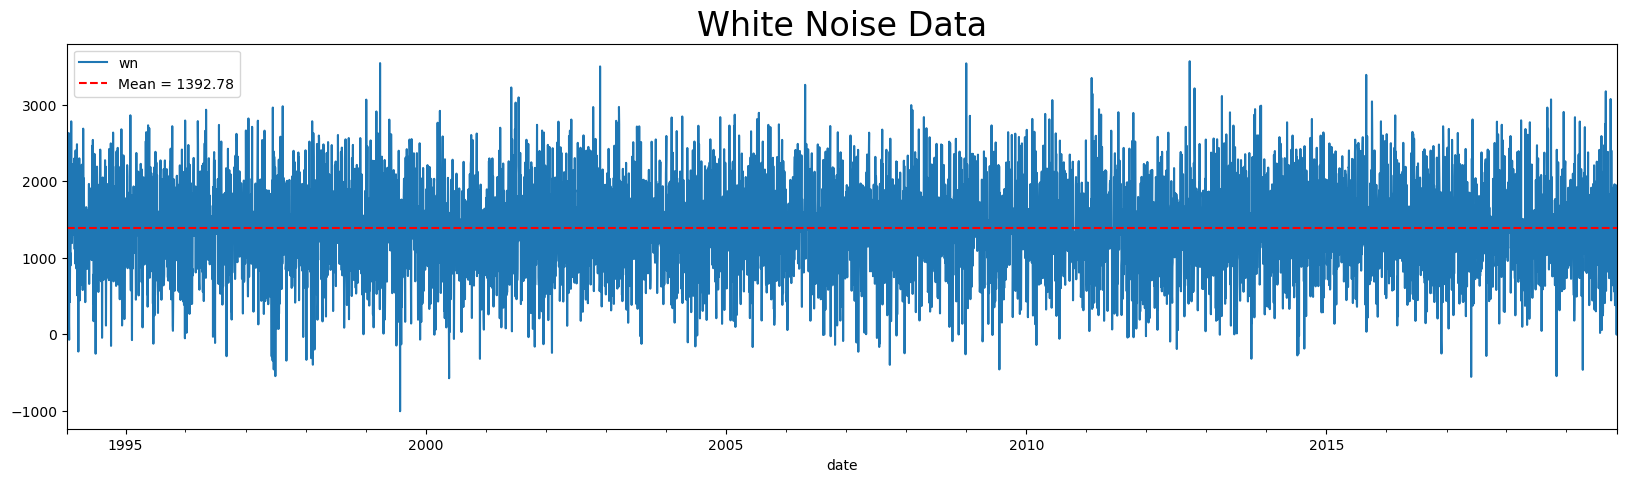

In [62]:
# Plotting line graph of each data value over the years
mean_val = df_train.wn.mean()
df_train.wn.plot(figsize=(20,5))
plt.title('White Noise Data',size=24)
plt.axhline(mean_val, linestyle='--',color='r', label=f"Mean = {mean_val:.2f}")
plt.legend()
plt.show()

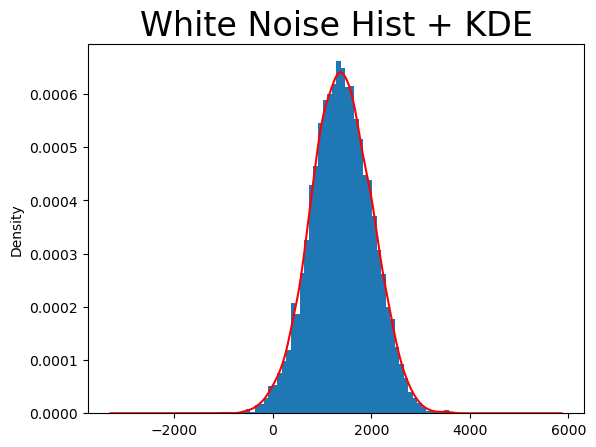

In [61]:
df_train['wn'].plot(kind='hist', bins=50, density=True)
df_train.wn.plot(kind='kde',color='r')
plt.title('White Noise Hist + KDE',size=24)
plt.show()

**Plotting Hist + KDE and line plot for Market Value data**

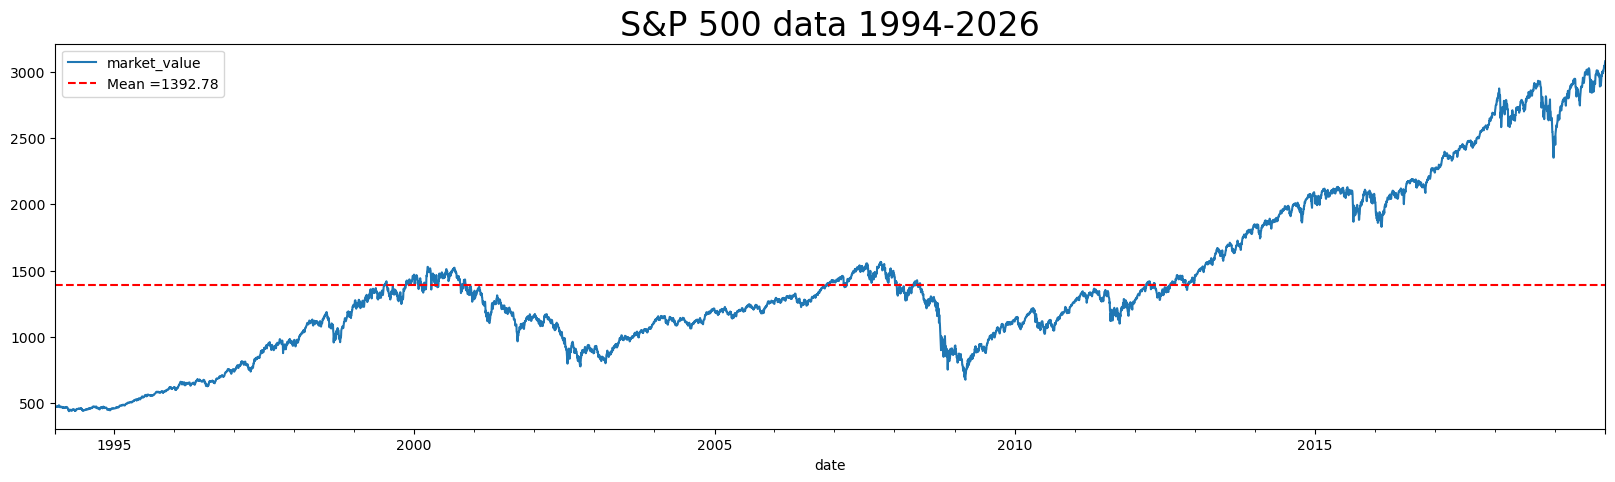

In [69]:
mean_val_mv = df_train.market_value.mean()
df_train.market_value.plot(figsize=(20,5))
plt.title('S&P 500 data 1994-2026',size=24)
plt.axhline(mean_val, linestyle="--", color='r', label = f'Mean ={mean_val:.2f}')
plt.legend()
plt.show()

### Random Walk

In [71]:
rw = pd.read_csv('RandWalk.csv')

In [ ]:
rw.date = pd.to_datetime(rw.date, dayfirst=True) # To datetime and in yyyy/mm/dd

In [ ]:
# setting date as indexes 
rw.set_index('date',inplace=True)

In [ ]:
rw.asfreq('b')
rw.price = rw.price.ffill() # filling the missing prices with previous day prices

In [ ]:
rw.isna().sum() # checking if there is any nan values left

price    0
dtype: int64

In [76]:
rw.head() # And we are done!!

,price
date,
1994-01-07,1122.139662
1994-01-08,1135.238562
1994-01-09,1109.897831
1994-01-10,1080.347860
1994-01-11,1082.095245


### Stationarity

### Seasonality

### ACF

### PACF